In [154]:
# from google.colab import drive # remove the cell if not using colab
# drive.mount('/content/drive')

In [155]:
import pandas as pd
import numpy as np
from numpy.typing import NDArray
from pathlib import Path
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.base import ClassifierMixin


data_dir_name = '01_przetwarzanie_wizualizacja_danych'
search_roots = (Path.cwd(), *Path.cwd().parents)
base_path = next(
    (root / data_dir_name for root in search_roots
     if (root / data_dir_name / 'titanic.csv').exists()),
    None,
)

random_state = 42
cv = 5

def print_grid_results(grid_serch : GridSearchCV):
    print("best setting:", grid_serch.best_params_ )
    print("crossvalidation result: ", round(grid_serch.best_score_, 3))
    print("Accuracy (test):     ", round(grid_serch.score(X_test, y_test), 3))

def print_cross_result(
    cross_results: NDArray[np.float64],
    classifier: ClassifierMixin,
) -> None:
    print(f'Accuracy results (train) {cross_results}')
    print(f'Mean Accuracy (train): {cross_results.mean():.3f} + /- {cross_results.std():.3f}')
    print(f'Mean MSE (train): {1 - cross_results.mean():.3f}')
    print(f'Accuracy (test): {classifier.score(X_test, y_test):.3f}')



# Klasyfikacja pasażerów Titanica
Nie wiemy czy dla DiCaprio było miejsce na drzwiach, ale wiemy że grdyby był tam Wojfer87 to by z nimi wyciskał pompki na górze lodowej. Teraz twoja pora na wyciskanie.
#Twoje zadnie to:
**stworzenie modelu przewidującego szanse przeżycia katastrofy Titanica**.

![https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png](https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png "Wojfer")



## Twoim celem będzie jest wytrenowanie modeli do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

Poniżej znajdziesz pytania, które mogą być pomocne w zadaniu:

- Czego nauczyło Cię o badanym zbiorze danych poprzednie zadanie? Jak możesz wykorzystać wyciągnięte z niego wnioski w procesie tworzenia modelu?
- Jak przeprowadzenie standaryzacji danych może wpływać na zachowanie modelu?
- Co mój model robi i w jaki sposób?
- Jak nie przetrenować wybranego modelu?
- Jaki wynik klasyfikacji możemy uznać za *dobry*?


Wymagania:
- Wypisz obserwacje z pierwszego zadania, które pomogą Ci w tym. Co było przydatne, a co okazało się bezużyteczne?
- [Nie doprowadź](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) do ~~przecieku statku~~ wycieku danych (np. nie ucz modelu na danych testowych). Nauczone modele odpal na danych treningowych i testowych - opisz uzyskane wyniki.
- Stwórz baseline, czyli dla porównania sprawdź jak z zadaniem radzi sobie [Dummy Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html) (jeśli Twój docelowy model radzi sobie gorzej - uciekaj)
- Przeprowadź badania na dwóch wybranych modelach uczenia maszynowego (np. spośród: drzew decyzyjnych, SVC, MLP, KNN, z gwiazdką [XGBoost](https://xgboost.readthedocs.io/en/stable))
- W badaniach użyj wybranych metryk. Wybór uzasadnij.
- Dla każdego modelu wybierz co najmniej dwa hiperparametry i przeprowadź badania zależności wyników metryk od wartości hiperparametrów. Zwizualizuj wszystko ładnie, zastanów się dlaczego tak mogło być i wyciągnij i wypisz wnioski.
- Podsumuj przeprowadzone badania, wypisz wnioski.

Niezmiennie, zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Jeśli chcesz, możesz sprawdzić (przyjmując pewne założenia), jakie byłyby Twoje szanse na Titanicu.

Uwaga! Jeśli Titanic to dla Ciebie nic i baaaaardzo chcesz to możesz w ramach tego zadania zająć się [bardziej wymagającym](https://archive.ics.uci.edu/dataset/365/polish+companies+bankruptcy+data) zbiorem.

# Zadanie

## Fucntrion def

In [156]:
titanic_df = pd.read_csv(base_path / 'titanic_results.csv', index_col='PassengerId')
titanic_df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,WithFamily,WasChild,Sex_male,Embarked_Q,Embarked_S,Cabin_A,Cabin_B,Cabin_C,Cabin_D,Cabin_E,Cabin_F,Cabin_G,Cabin_T,Cabin_U
PassengerId,,,,,,,,,,,,,,,,,,,,
1,0,3,22.0,1,0,7.2500,1,0,1,0,1,False,False,False,False,False,False,False,False,True
2,1,1,38.0,1,0,71.2833,1,0,0,0,0,False,False,True,False,False,False,False,False,False
3,1,3,26.0,0,0,7.9250,0,0,0,0,1,False,False,False,False,False,False,False,False,True
4,1,1,35.0,1,0,53.1000,1,0,0,0,1,False,False,True,False,False,False,False,False,False
5,0,3,35.0,0,0,8.0500,0,0,1,0,1,False,False,False,False,False,False,False,False,True


## Skalowanie

In [157]:
titanic_df = pd.read_csv(base_path / 'titanic_results.csv', index_col='PassengerId')
titanic_df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,WithFamily,WasChild,Sex_male,Embarked_Q,Embarked_S,Cabin_A,Cabin_B,Cabin_C,Cabin_D,Cabin_E,Cabin_F,Cabin_G,Cabin_T,Cabin_U
PassengerId,,,,,,,,,,,,,,,,,,,,
1,0,3,22.0,1,0,7.2500,1,0,1,0,1,False,False,False,False,False,False,False,False,True
2,1,1,38.0,1,0,71.2833,1,0,0,0,0,False,False,True,False,False,False,False,False,False
3,1,3,26.0,0,0,7.9250,0,0,0,0,1,False,False,False,False,False,False,False,False,True
4,1,1,35.0,1,0,53.1000,1,0,0,0,1,False,False,True,False,False,False,False,False,False
5,0,3,35.0,0,0,8.0500,0,0,1,0,1,False,False,False,False,False,False,False,False,True


### Robust Age

In [158]:
age_mean = titanic_df['Age'].mean()
age_iqr = titanic_df["Age"].quantile(0.75) - titanic_df["Age"].quantile(0.25)
titanic_df['Age'] = titanic_df['Age'].apply(lambda x: (x - age_mean) /(age_iqr))


### Robust Fare

In [159]:

fare_mean = titanic_df['Fare'].mean()
fare_iqr = titanic_df["Fare"].quantile(0.75) - titanic_df["Fare"].quantile(0.25)
titanic_df['Fare'] = titanic_df['Fare'].apply(lambda x: (x - fare_mean) /(fare_iqr))


In [160]:
titanic_df.head()


,Survived,Pclass,Age,SibSp,Parch,Fare,WithFamily,WasChild,Sex_male,Embarked_Q,Embarked_S,Cabin_A,Cabin_B,Cabin_C,Cabin_D,Cabin_E,Cabin_F,Cabin_G,Cabin_T,Cabin_U
PassengerId,,,,,,,,,,,,,,,,,,,,
1,0,3,-0.592253,1,0,-1.099785,1,0,1,0,1,False,False,False,False,False,False,False,False,True
2,1,1,0.638516,1,0,1.642541,1,0,0,0,0,False,False,True,False,False,False,False,False,False
3,1,3,-0.284561,0,0,-1.070877,0,0,0,0,1,False,False,False,False,False,False,False,False,True
4,1,1,0.407747,1,0,0.863813,1,0,0,0,1,False,False,True,False,False,False,False,False,False
5,0,3,0.407747,0,0,-1.065524,0,0,1,0,1,False,False,False,False,False,False,False,False,True


## Podział na zbiory

In [161]:
from sklearn.model_selection import train_test_split

X = titanic_df.drop(columns='Survived')
y = titanic_df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2 , random_state=random_state, stratify=y
)



## Dummy Clasifier

Accuracy (train): 0.617
Accuracy (test):  0.615
              precision    recall  f1-score   support

           0       0.61      1.00      0.76       110
           1       0.00      0.00      0.00        69

    accuracy                           0.61       179
   macro avg       0.31      0.50      0.38       179
weighted avg       0.38      0.61      0.47       179



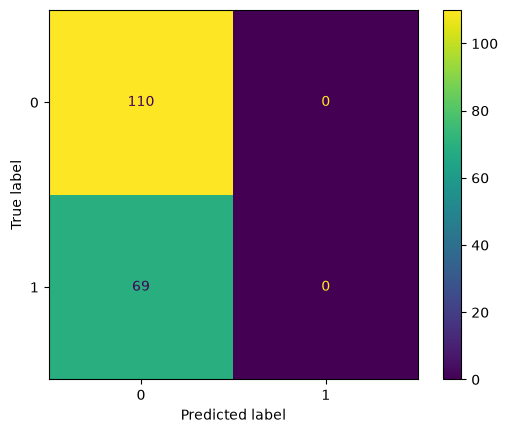

In [162]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay


dummy_classifier = DummyClassifier(strategy='most_frequent',random_state=random_state)
dummy_classifier.fit(X_train, y_train)
y_pred = dummy_classifier.predict(X_test)

print(f'Accuracy (train): {dummy_classifier.score(X_train, y_train):.3f}')
print(f'Accuracy (test):  {dummy_classifier.score(X_test, y_test):.3f}')
print(classification_report(y_test, y_pred, zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

## KNN

Accuracy (train): 0.850
Accuracy (test):  0.777
              precision    recall  f1-score   support

           0       0.81      0.84      0.82       110
           1       0.72      0.68      0.70        69

    accuracy                           0.78       179
   macro avg       0.77      0.76      0.76       179
weighted avg       0.77      0.78      0.78       179



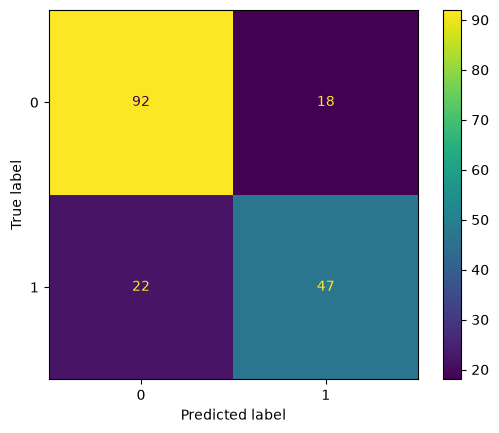

In [163]:

from sklearn.neighbors import KNeighborsClassifier


knn_classifier = KNeighborsClassifier(n_neighbors=5, 
                                      metric='euclidean')

knn_classifier.fit(X_train, y_train)
y_pred = knn_classifier.predict(X_test)

print(f'Accuracy (train): {knn_classifier.score(X_train, y_train):.3f}')
print(f'Accuracy (test):  {knn_classifier.score(X_test, y_test):.3f}')
print(classification_report(y_test, y_pred, zero_division=0))
y_pred = knn_classifier.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

### Kroswalidacja

In [164]:
from sklearn.model_selection import cross_val_score

knn_cross_results = cross_val_score(knn_classifier, X_train, y_train, cv=cv, scoring='accuracy')
print_cross_result(knn_cross_results, knn_classifier)


Accuracy results (train) [0.75524476 0.78321678 0.81690141 0.83802817 0.83098592]
Mean Accuracy (train): 0.805 + /- 0.031
Mean MSE (train): 0.195
Accuracy (test): 0.777


### Grid Search

In [165]:


knnn_param_grid = {
    'n_neighbors' :   [x for x in range(1,22,2)], #from 1 to 21 , step by 2
    'metric' :['cosine', 'euclidean']
}

knn_grid_search = GridSearchCV(
    knn_classifier,
    param_grid=knnn_param_grid,
    cv = cv,
    scoring='accuracy',
    return_train_score=True
)
knn_grid_search.fit(X_train, y_train)
print_grid_results(knn_grid_search)




best setting: {'metric': 'euclidean', 'n_neighbors': 3}
crossvalidation result:  0.818
Accuracy (test):      0.765


Model KNN jest stabilny na różne grupy treningowe badanego zbioru

### Training scope MSE


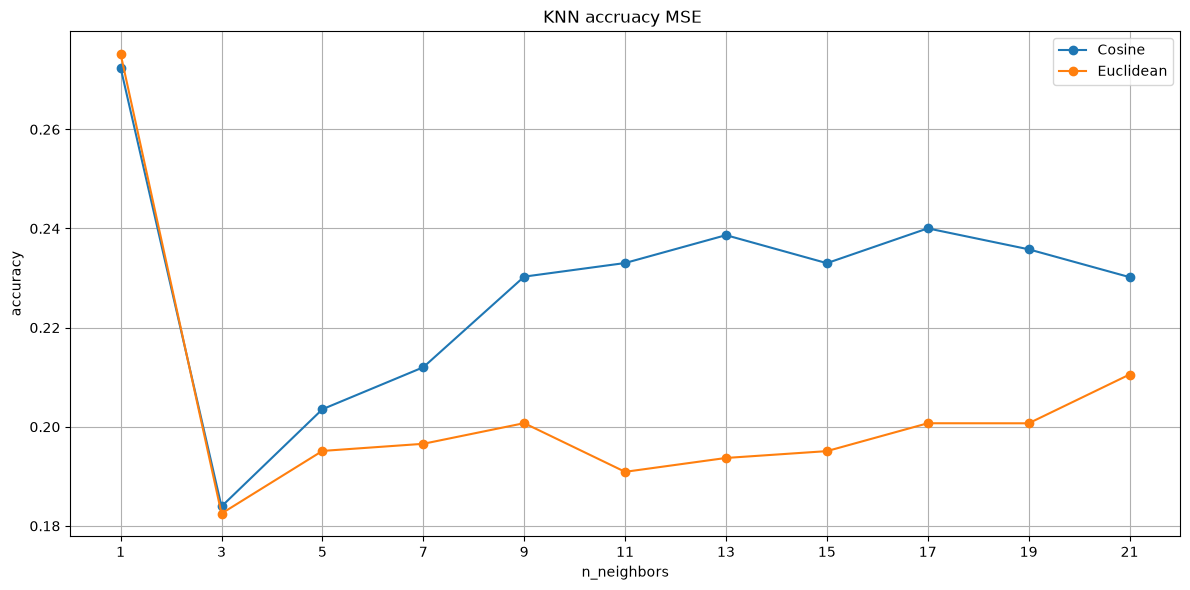

In [166]:
knn_grid_search_results = pd.DataFrame(knn_grid_search.cv_results_)
knn_grid_search_results = knn_grid_search_results[
    [
        "param_metric",
        "param_n_neighbors",
        "mean_test_score",

    ]]
knn_grid_search_results["classification_error"] = 1 - knn_grid_search_results['mean_test_score']

knn_cosine = knn_grid_search_results[
    knn_grid_search_results["param_metric"] == "cosine"
].sort_values("param_n_neighbors")



knn_euclidean = knn_grid_search_results[
    knn_grid_search_results["param_metric"] == "euclidean"
].sort_values("param_n_neighbors")



plt.figure(figsize=(12, 6))

plt.plot(knn_cosine["param_n_neighbors"], knn_cosine["classification_error"], marker="o", label="Cosine")
plt.plot(knn_euclidean["param_n_neighbors"], knn_euclidean["classification_error"], marker="o", label="Euclidean")

plt.xlabel("n_neighbors")
plt.xticks(range(1, 22, 2))
plt.ylabel("accuracy")
plt.title("KNN accruacy MSE ")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()
    

Miara `Cosine` spisue się gorzej od `Euclidean`. Próbki w obrębie danej grupy są bliże do siebie średnią wartości cech, niż pod względem podobieństwa pomiędzy sobą (stosunek pomiędzy cechami próbki).

Najmniejsze MSE osiągamy dla `n_neighbors` = 5. Taka wartość zapewnia jak najmijesze MSE accuracy klasyfikatora.  Powyżęj tej liczby MSE rośnie. Zbyt duże `n` powoduję faworyzacje grupy większościowej.

### Test scope MSE

Accuracy (train): 0.826
Accuracy (test):  0.810
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       110
           1       0.77      0.72      0.75        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179



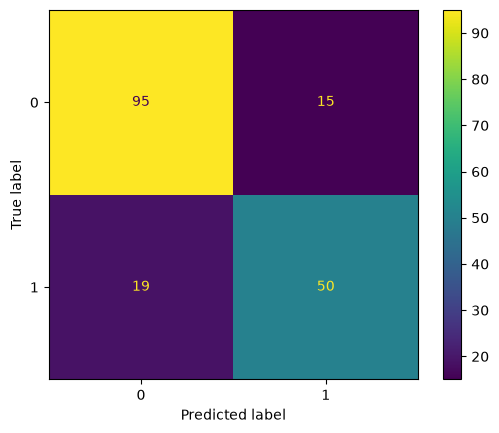

In [167]:
from sklearn.svm import SVC

X = titanic_df.drop(columns='Survived')
y = titanic_df['Survived']


svc_classifier = SVC(random_state=42)
svc_classifier.fit(X_train, y_train)
y_pred = svc_classifier.predict(X_test)

print(f'Accuracy (train): {svc_classifier.score(X_train, y_train):.3f}')
print(f'Accuracy (test):  {svc_classifier.score(X_test, y_test):.3f}')
print(classification_report(y_test, y_pred, zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)



### Kroswalidacja

In [168]:


svc_cross_results = cross_val_score(svc_classifier, X_train, y_train, cv=cv, scoring='accuracy')
print_cross_result(svc_cross_results, svc_classifier)


Accuracy results (train) [0.76923077 0.81118881 0.83098592 0.80985915 0.83098592]
Mean Accuracy (train): 0.810 + /- 0.023
Mean MSE (train): 0.190
Accuracy (test): 0.810


### Grid Search


In [169]:
kernel_types = ('linear', 'poly', 'rbf', 'sigmoid')
C = [0.1,1,10,100]

svc_param_grids = {
    'kernel': kernel_types,
    'C': C
}



svc_grid_search = GridSearchCV(
    svc_classifier,
    param_grid= svc_param_grids,
    cv = cv,
    scoring='accuracy',
    return_train_score=True,
)

svc_grid_search.fit(X_train, y_train)

print_grid_results(svc_grid_search)

best setting: {'C': 100, 'kernel': 'rbf'}
crossvalidation result:  0.816
Accuracy (test):      0.771


### Training scope MSE


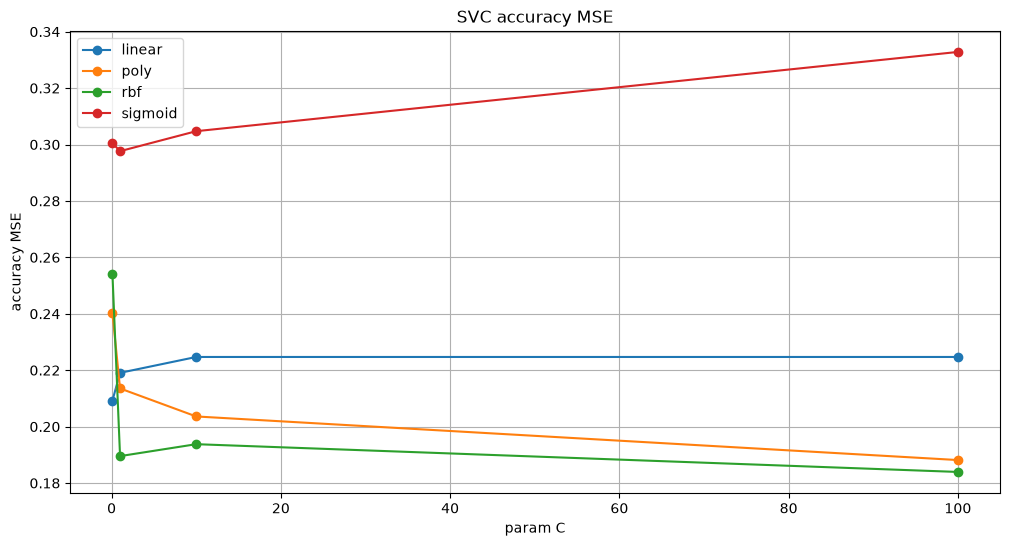

In [170]:
svc_grid_search_results = pd.DataFrame(svc_grid_search.cv_results_)
svc_grid_search_results = svc_grid_search_results[
    [
    "param_kernel", 
    "param_C", 
    "mean_test_score"
    ]]
svc_grid_search_results["mse_accuracy"] = 1 - svc_grid_search_results["mean_test_score"]



plt.figure(figsize=(12,6))
plt.title('SVC accuracy MSE')
plt.xlabel('param C')
plt.ylabel('accuracy MSE')
for k in kernel_types :
        df = svc_grid_search_results.loc[svc_grid_search_results["param_kernel"] == k].sort_values("param_C")
        plt.plot(df["param_C"], df["mse_accuracy"], label= k, marker='o' )
plt.legend()
plt.grid()
plt.show()



Najmiejszy blą osiągnął `rbf` dla `C` = 100 . Wynika to z tego iż jest dzieli on próbki krzywą, przez co może najlepiej się "dopasować". Daje to zdecydoiwanie lepszy wynik niż np. `linear`. 
`C` informuje nas o stopniu dopasownia krzywej podziału. Dużę `C` czyli mniejsza tolerancja błędów może prowiadzić do zwiększenia `MSE` w `accuracy`



## Podsumowanie

Po przeprowadzonych analizach udało wyszkolić KNN oraz SVC następująco

### Model przed GridSearch

| Model | Accuracy train | Validation accuracy | Accuracy test | Diff (train - test) |
| --- | ---: | ---: | ---: | ---: |
| KNN | 0.805 | 0.805 | 0.777 | 0.028 |
| SVC | 0.805 | 0.810 | 0.810 | -0.005 |

---

### Model po GridSearch

| Model | Accuracy train | Validation accuracy | Accuracy test | Diff (train - test) |
| --- | ---: | ---: | ---: | ---: |
| KNN | 0.881 | 0.818 | 0.765 | 0.116 |
| SVC | 0.902 | 0.816 | 0.771 | 0.131 |

### Wnioski

Zastosowanie GridSearchCV nieznacznie poprawiło średnią dokładność walidacyjną: z 0.805 do 0.818 dla KNN oraz z 0.810 do 0.816 dla SVC. Jednocześnie wzrosła dokładność na zbiorze treningowym, ale nie przełożyło się to na poprawę wyników testowych. Dla KNN dokładność testowa spadła z 0.777 do 0.765, a dla SVC z 0.810 do 0.771. Większa różnica między dokładnością treningową a walidacyjną i testową wskazuje na silniejsze przeuczenie modeli po doborze hiperparametrów. 


